<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/111language_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import optuna
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 12.0 MB/s eta 0:00:00


In [34]:
df=pd.read_csv('/content/Language Detection.csv',encoding='latin-1')
df.sample(10)

,Text,Language
48,"[16] During the Neoproterozoic era, freezing t...",English
8354,En wiki har sÃ¥ledes stora likheter med ett we...,Sweedish
4358,Artikelen op Wikipedia scoren over het algemee...,Dutch
2140,"à® à®¤à®©à¯ à®ªà®¿à®©à¯à®©à®°à¯, âà®ªà®²à...",Tamil
6738,Administratorer kan fÃ¥ taget deres rettighede...,Danish
95,Though generally recognized as several 'separa...,English
2212,à®à®©à®µà¯ à®¨à¯à®à¯à®à®³à¯ à®à®à¯à®...,Tamil
1832,à´à´¨à´¿à´àµà´àµ à´ à´±à´¿à´¯à´¿à´²àµà´²...,Malayalam
1686,à´ à´¤à´¿à´¨à´¾àµ½ à´¨à´¿à´àµà´àµ¾ à´à´°àµ...,Malayalam
2097,"à®à®©à®¿à®©à¯à®®à¯, à®µà¯à®µà¯à®µà¯à®±à¯...",Tamil


In [9]:
df['Language'].value_counts()

,count
Language,
English,1385
French,1014
Spanish,819
Portugeese,739
Italian,698
Russian,692
Sweedish,676
Malayalam,594
Dutch,546


In [11]:
df.drop_duplicates(inplace=True)
# Drops rows if "hindi" is found in any column


<Axes: xlabel='Language'>

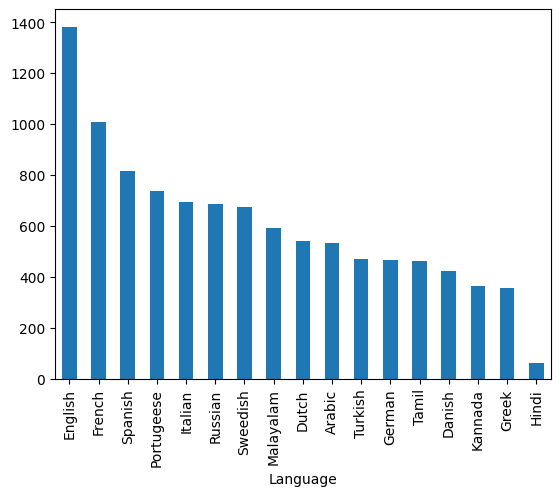

In [12]:
# plotting the bargraph
df['Language'].value_counts().plot(kind='bar')

In [39]:
df.drop(df[df['Language'] == 'Hindi'].index, inplace=True)
df.drop(df[df['Language'] == 'Kannada'].index, inplace=True)
df.drop(df[df['Language'] == 'Tamil'].index, inplace=True)

<Axes: xlabel='Language'>

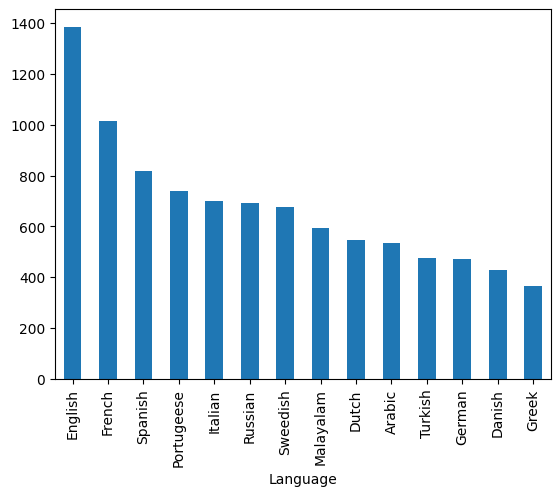

In [40]:
df['Language'].value_counts().plot(kind='bar')

In [59]:
df.sample(20)

,Text,Language
5863,,Greek
6674,ñ,Russian
4158,faire de plan,French
1300,wondering yo could help,English
4748,pop en het meest grappige dat ze oneindig veel...,Dutch
606,estimate reinvestment industrial organization ...,English
1020,evolvement ai system raise lot question realm ...,English
4117,pardon,French
8920,hade som en och den andra hade en enorm jag sk...,Sweedish
7606,sei molto meglio del problema su cui piangi no...,Italian


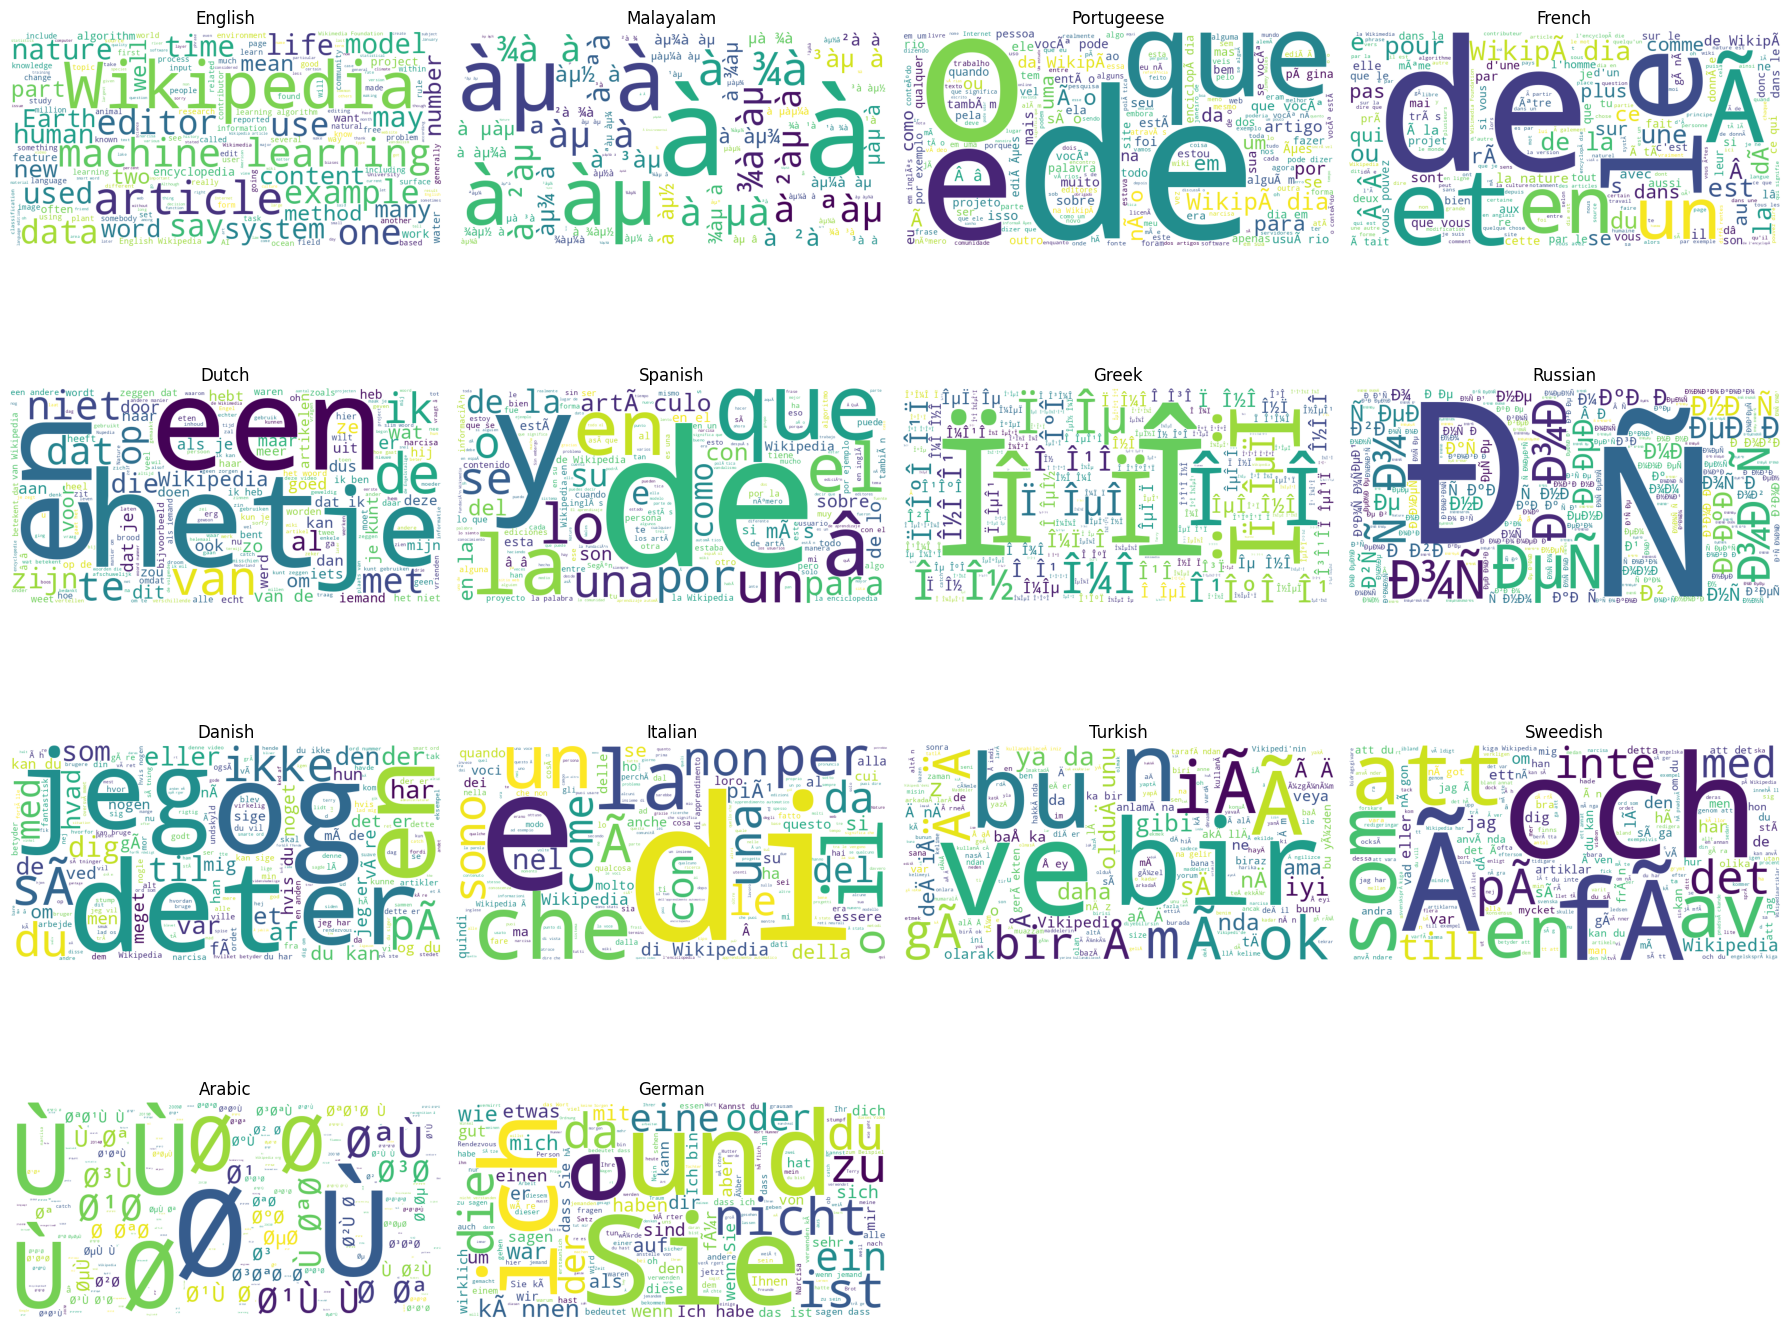

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    background_color='white',
    width=800,
    height=400
)

languages = df['Language'].unique()

plt.figure(figsize=(18, 18))

for i, lang in enumerate(languages):
    text = ' '.join(df[df['Language'] == lang]['Text'])

    plt.subplot(5, 4, i + 1)
    plt.title(lang)
    plt.imshow(wordcloud.generate(text))
    plt.axis('off')

plt.tight_layout()
plt.show()


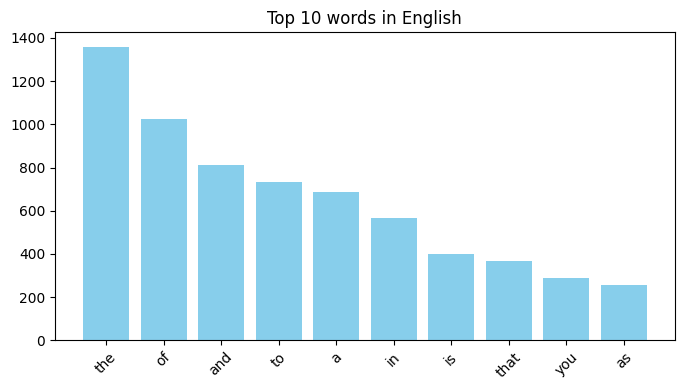

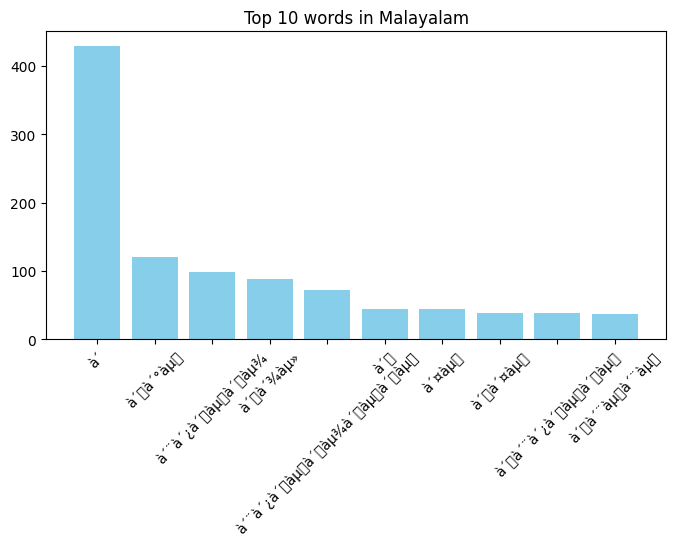

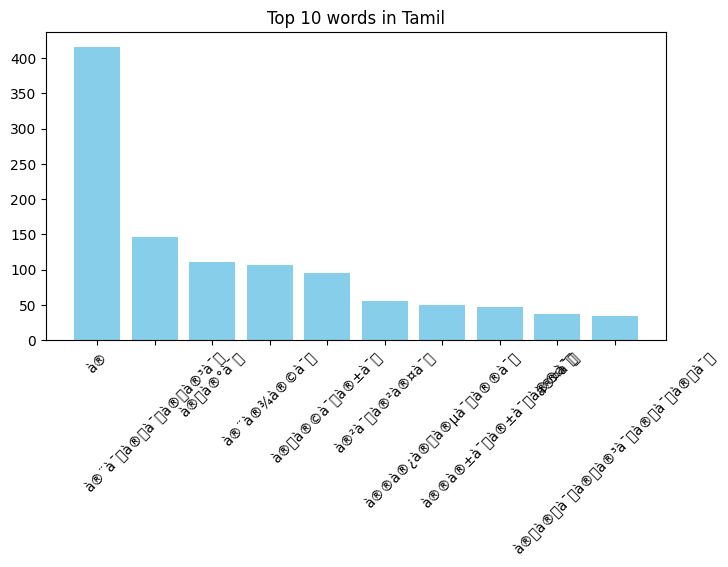

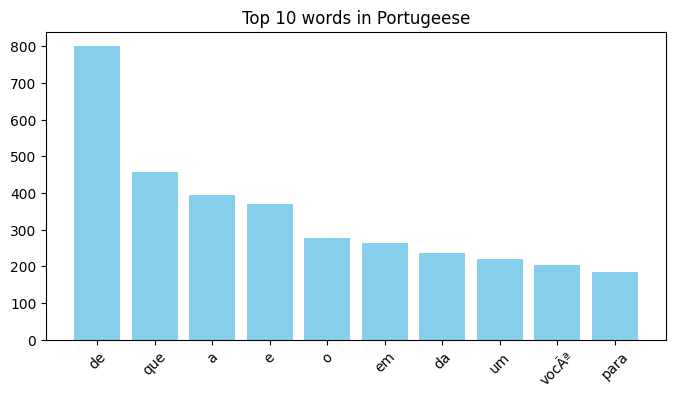

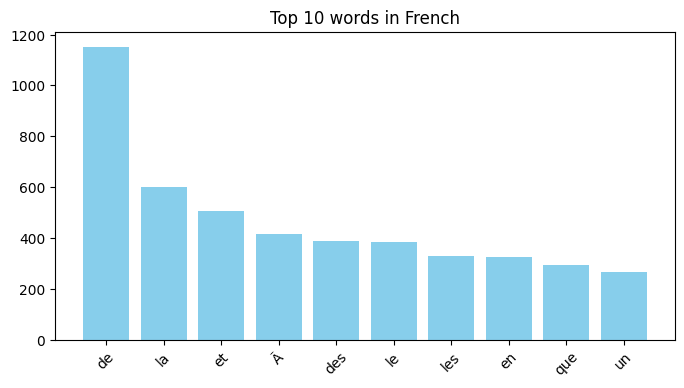

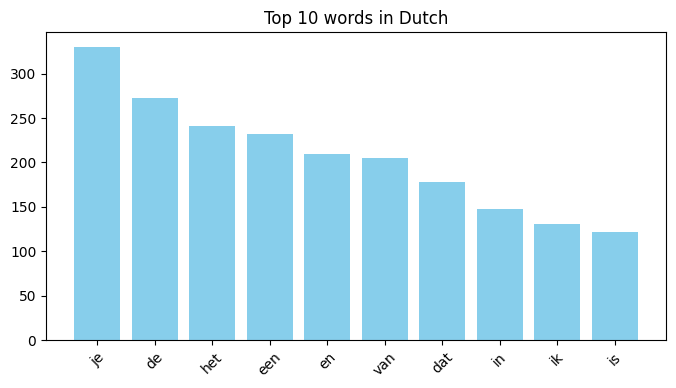

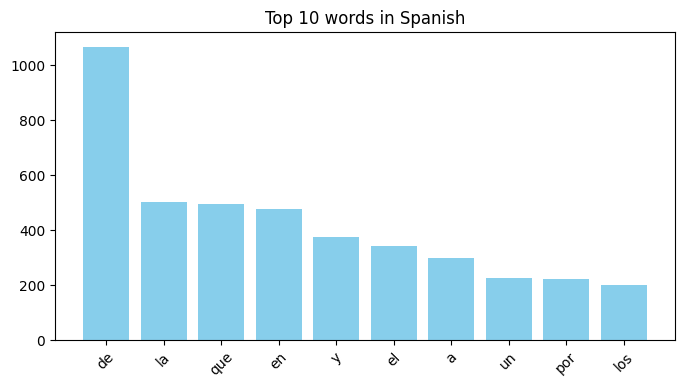

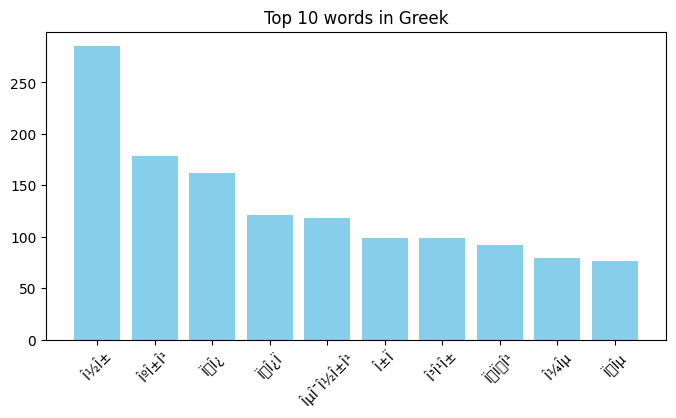

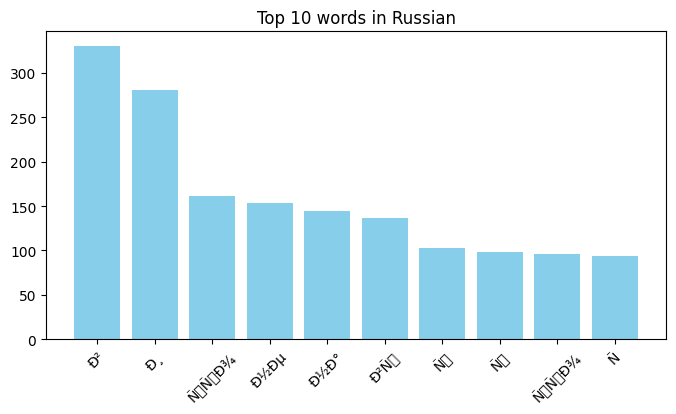

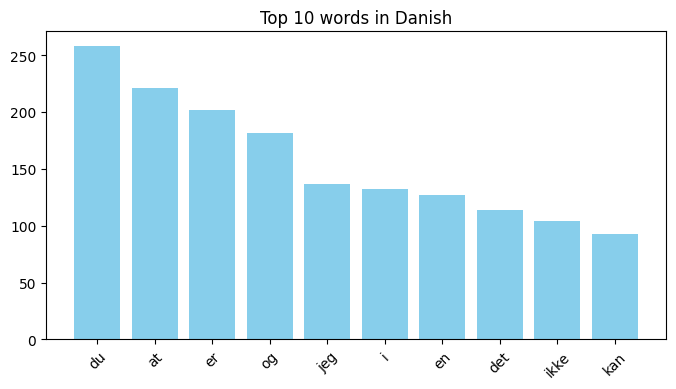

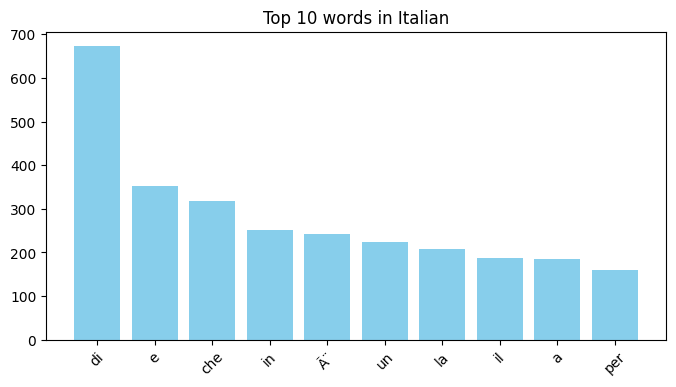

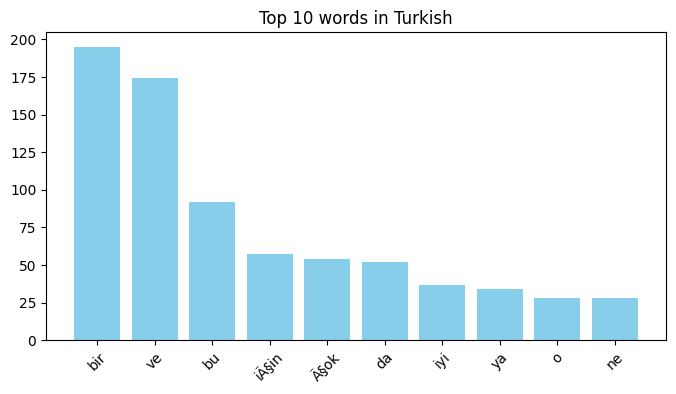

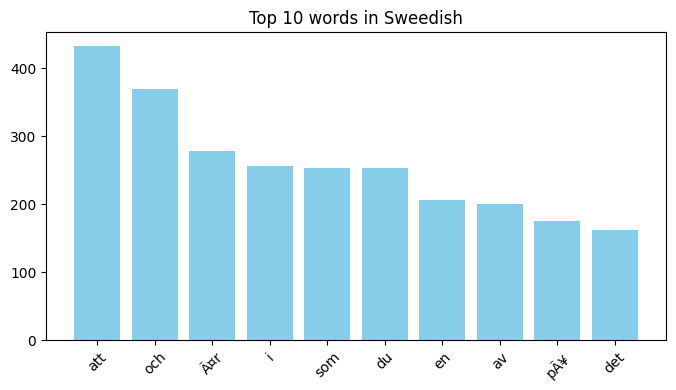

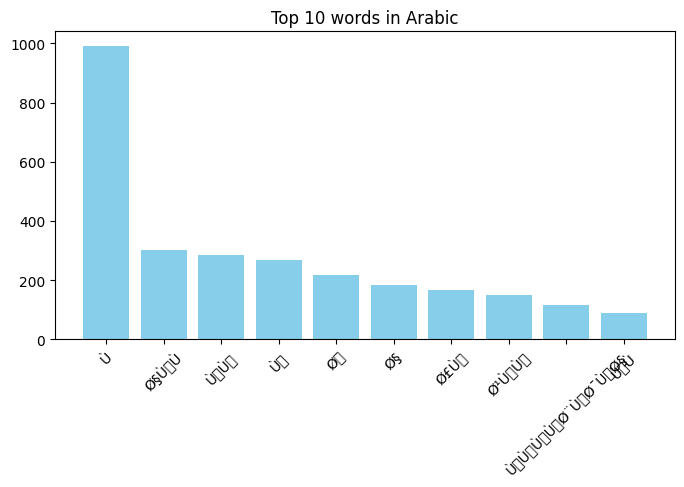

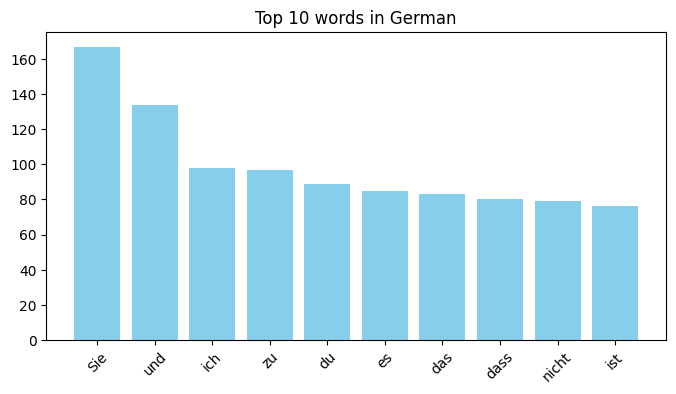

In [16]:
for lan in languages:
  text="".join(df[df['Language']==lan]['Text']).split()
  common_words=Counter(text).most_common(10)
  words,counts=zip(*common_words)

  plt.figure(figsize=(8,4))
  plt.bar(words, counts, color='skyblue')
  plt.title(f'Top 10 words in {lan}')
  plt.xticks(rotation=45)
  plt.show()




text preprocessing

In [43]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word.isalpha() and word not in stop_words]
    return ' '.join(words)

df['Text'] = df['Text'].apply(preprocess_text)

In [44]:
X=df['Text']
y=df['Language']

In [45]:
# test train split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
# encoder of y
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)


vectorizing and Modeling using optuna

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial, X, y):
    # vectorizer hyperparameters
    ngram_max = trial.suggest_int('ngram_max', 2, 5)
    max_features = trial.suggest_categorical('max_features', [30000, 50000, 80000, None])
    min_df = trial.suggest_int('min_df', 1, 3)

    vectorizer = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(1, ngram_max),
        max_features=max_features,
        min_df=min_df,
        sublinear_tf=True
    )

    model_name = trial.suggest_categorical('model', ['LogisticRegression', 'LinearSVC', 'RandomForestClassifier', 'NaiveBayes'])

    if model_name == 'LogisticRegression':
        model = LogisticRegression(
            C=trial.suggest_float('C', 1e-3, 100, log=True),
            max_iter=1000,
            class_weight='balanced'
        )
    elif model_name == 'LinearSVC':
        model = LinearSVC(
            C=trial.suggest_float('C', 1e-3, 100, log=True),
            class_weight='balanced'
        )
    elif model_name == 'RandomForestClassifier':
        model = RandomForestClassifier(
            max_depth=trial.suggest_int('max_depth', 2, 20),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        )
    elif model_name == 'NaiveBayes':
        model = MultinomialNB(
            alpha=trial.suggest_float('alpha', 1e-10, 1.0, log=True),
            fit_prior=trial.suggest_categorical('fit_prior', [True, False])
        )
    else:
        raise ValueError("Invalid model type")

    pipe = Pipeline([('tfidf', vectorizer), ('clf', model)])
    score = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=-1, error_score='raise')
    return score.mean()

In [58]:
# running the study
study=optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial,X_train,y_train),n_trials=50)
best_params = study.best_params.copy()
model_name = best_params.pop('model')
ngram_max = best_params.pop('ngram_max')
max_features = best_params.pop('max_features')
min_df = best_params.pop('min_df')

vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(1, ngram_max),
    max_features=max_features,
    min_df=min_df,
    sublinear_tf=True
)

if model_name == 'LogisticRegression':
    clf = LogisticRegression(**best_params, max_iter=1000, class_weight='balanced')
elif model_name == 'LinearSVC':
    clf = LinearSVC(**best_params, class_weight='balanced')
elif model_name == 'RandomForestClassifier':
    clf = RandomForestClassifier(**best_params, class_weight='balanced', n_jobs=-1, random_state=42)
else:
    clf = MultinomialNB(**best_params)

final_pipe = Pipeline([('tfidf', vectorizer), ('clf', clf)])
final_pipe.fit(X_train, y_train)   # raw text, not pre-vectorized X_train

print('Best trial: score {}, params {}'.format(study.best_trial.value, study.best_trial.params))
y_pred = final_pipe.predict(X_test)   # raw text
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



[I 2026-08-31 09:09:08,602] A new study created in memory with name: no-name-106ac8e8-1887-4288-93c3-e33a92823725
[I 2026-08-31 09:10:07,346] Trial 0 finished with value: 0.8846900105464485 and parameters: {'ngram_max': 4, 'max_features': 50000, 'min_df': 1, 'model': 'LogisticRegression', 'C': 30.516212051594835}. Best is trial 0 with value: 0.8846900105464485.
[I 2026-08-31 09:10:17,884] Trial 1 finished with value: 0.8709011587159834 and parameters: {'ngram_max': 3, 'max_features': 30000, 'min_df': 2, 'model': 'LinearSVC', 'C': 0.004557785330868645}. Best is trial 0 with value: 0.8846900105464485.
[I 2026-08-31 09:10:22,113] Trial 2 finished with value: 0.804978145605177 and parameters: {'ngram_max': 3, 'max_features': None, 'min_df': 2, 'model': 'NaiveBayes', 'alpha': 2.1355818871090564e-10, 'fit_prior': True}. Best is trial 0 with value: 0.8846900105464485.
[I 2026-08-31 09:10:28,412] Trial 3 finished with value: 0.8496258794179555 and parameters: {'ngram_max': 2, 'max_features': N

Best trial: score 0.888163706170195, params {'ngram_max': 5, 'max_features': None, 'min_df': 3, 'model': 'LinearSVC', 'C': 0.8372972484349048}
Accuracy: 0.895656779661017
              precision    recall  f1-score   support

      Arabic       1.00      0.75      0.86       106
      Danish       0.98      0.96      0.97        84
       Dutch       0.97      0.97      0.97       113
     English       0.97      0.98      0.97       274
      French       1.00      0.97      0.99       208
      German       0.97      0.97      0.97       104
       Greek       0.98      0.62      0.76        68
     Italian       0.98      0.99      0.99       144
   Malayalam       0.42      0.94      0.58       118
  Portugeese       0.93      0.99      0.96       140
     Russian       0.97      0.38      0.55       152
     Spanish       0.98      0.96      0.97       159
    Sweedish       0.95      0.98      0.96       134
     Turkish       0.96      0.87      0.91        84

    accuracy     

<Axes: >

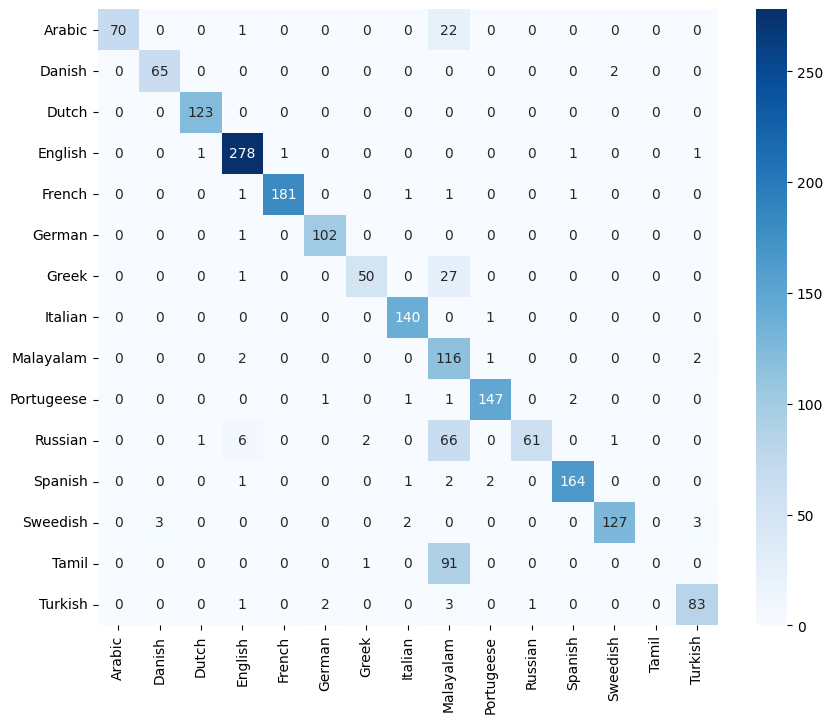

In [27]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, columns=label_encoder.classes_, index=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')


**Predict the language**

In [60]:
def predict_language(text):
    pred_encoded = final_pipe.predict([text])
    pred_label = label_encoder.inverse_transform(pred_encoded)
    return pred_label[0]

# example
print(predict_language("Bonjour, comment ça va?"))
print(predict_language("This is a test sentence"))
print(predict_language("Hvad koster det"))
print(predict_language("Taler du engelsk"))

French
English
Danish
Danish
